# Distortion results

Load distortion metrics for BasicPitch, CREPE, and Librosa, merge with the manifest for level/class tags, and generate summary tables and plots.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.3f}".format

out_dir = Path("Dist_Results")
out_dir.mkdir(exist_ok=True)
# slightly higher DPI for PPT-friendly exports
plt.rcParams["figure.dpi"] = 150


In [6]:
manifest = pd.read_csv("manifest_dist.csv")
metric_files = {
    "basic_pitch": "basic_pitch_distortion.csv",
    "crepe": "crepe_distortion.csv",
    "librosa": "librosa_distortion.csv",
}

frames = []
for model, path in metric_files.items():
    df = pd.read_csv(path)
    df = df[df["filename"].isin(manifest["track_id"])].copy()
    df = df.merge(manifest, left_on="filename", right_on="track_id", how="left")
    df["model"] = model
    frames.append(df)

metrics = pd.concat(frames, ignore_index=True)
metrics = metrics[["filename", "model", "class_tag", "level_tag", "OA", "RPA", "RCA", "VR"]]

# Clean baselines per model for loss computation
clean_files = {
    "basic_pitch": "basic_pitch_clean.csv",
    "crepe": "crepe_clean.csv",
    "librosa": "librosa_clean.csv",
}
clean_means = []
for model, path in clean_files.items():
    df = pd.read_csv(path)
    df = df[df["filename"].isin(manifest["track_id"])].copy()
    clean_means.append(
        df[["OA", "RPA", "RCA", "VR"]].mean().to_frame().T.assign(model=model)
    )
clean_means = pd.concat(clean_means, ignore_index=True).set_index("model")

metrics.head()


,filename,model,class_tag,level_tag,OA,RPA,RCA,VR
0,CelestialShore_DieForUs_STEM_02,basic_pitch,vocal,heavy,0.627,0.906,0.905,0.641
1,MusicDelta_GriegTrolltog_STEM_07,basic_pitch,instrument,medium,0.737,0.534,0.532,0.755
2,AimeeNorwich_Child_STEM_04,basic_pitch,vocal,heavy,0.874,0.949,0.949,0.884
3,SecretMountains_HighHorse_STEM_09,basic_pitch,vocal,medium,0.669,0.826,0.821,0.724
4,CelestialShore_DieForUs_STEM_01,basic_pitch,vocal,medium,0.689,0.895,0.893,0.706


## Summary tables
- Overall mean metrics per model (best highlighted)
- Mean metrics by distortion level (light/medium/heavy)
- Mean metrics by source type (instrument vs vocal)
- Loss vs clean (overall and by level; best/worst highlighted)

In [7]:
overall_table = (
    metrics.groupby("model")[["OA", "RPA", "RCA", "VR"]]
    .mean()
    .sort_values("OA", ascending=False)
)

level_table = metrics.groupby(["model", "level_tag"])[["OA", "RPA", "RCA", "VR"]].mean()
class_table = metrics.groupby(["model", "class_tag"])[["OA", "RPA", "RCA", "VR"]].mean()

# Loss vs clean (distorted minus clean baseline)
delta_overall = overall_table.subtract(clean_means, axis=0)
delta_level_table = level_table.subtract(clean_means, level=0)

highlighted_overall = overall_table.style.highlight_max(axis=0, color="#ffe08a")
highlighted_delta_overall = delta_overall.style.highlight_max(axis=0, color="#b3ffb3")                                            .highlight_min(axis=0, color="#ffcccc")
highlighted_delta_level = delta_level_table.style.highlight_max(axis=0, color="#b3ffb3")                                            .highlight_min(axis=0, color="#ffcccc")

overall_table.to_csv(out_dir / "overall_table.csv")
level_table.to_csv(out_dir / "level_table.csv")
class_table.to_csv(out_dir / "class_table.csv")
delta_overall.to_csv(out_dir / "delta_overall_table.csv")
delta_level_table.to_csv(out_dir / "delta_level_table.csv")
highlighted_overall.to_html(out_dir / "overall_table_highlight.html")
highlighted_delta_overall.to_html(out_dir / "delta_overall_table_highlight.html")
highlighted_delta_level.to_html(out_dir / "delta_level_table_highlight.html")

display(highlighted_overall)
display(level_table)
display(class_table)
display(highlighted_delta_overall)
display(highlighted_delta_level)


,OA,RPA,RCA,VR
model,,,,
basic_pitch,0.723703,0.809819,0.794191,0.791361
librosa,0.670283,0.864602,0.809159,0.725926
crepe,0.478901,0.962535,0.920616,0.499688


OA   RPA   RCA    VR
model       level_tag                        
basic_pitch heavy     0.723 0.811 0.795 0.793
            light     0.719 0.810 0.796 0.783
            medium    0.729 0.808 0.792 0.798
crepe       heavy     0.506 0.951 0.905 0.535
            light     0.468 0.969 0.934 0.485
            medium    0.464 0.967 0.922 0.479
librosa     heavy     0.675 0.847 0.789 0.746
            light     0.675 0.873 0.819 0.727
            medium    0.661 0.874 0.819 0.704

OA   RPA   RCA    VR
model       class_tag                         
basic_pitch instrument 0.732 0.849 0.840 0.805
            vocal      0.715 0.769 0.747 0.778
crepe       instrument 0.546 0.945 0.908 0.578
            vocal      0.411 0.980 0.933 0.419
librosa     instrument 0.705 0.857 0.818 0.771
            vocal      0.635 0.873 0.801 0.680

,OA,RPA,RCA,VR
model,,,,
basic_pitch,0.002054,0.017499,0.021745,-0.006472
crepe,-0.038566,0.001861,0.001337,-0.040637
librosa,0.011347,0.013450,0.012571,0.002569


## Plots
- Mean metric comparison across models
- OA trend vs distortion level
- OA split by source type and level

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.26966710777846514, 0.4568837962313781, 0.39739568702782224)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

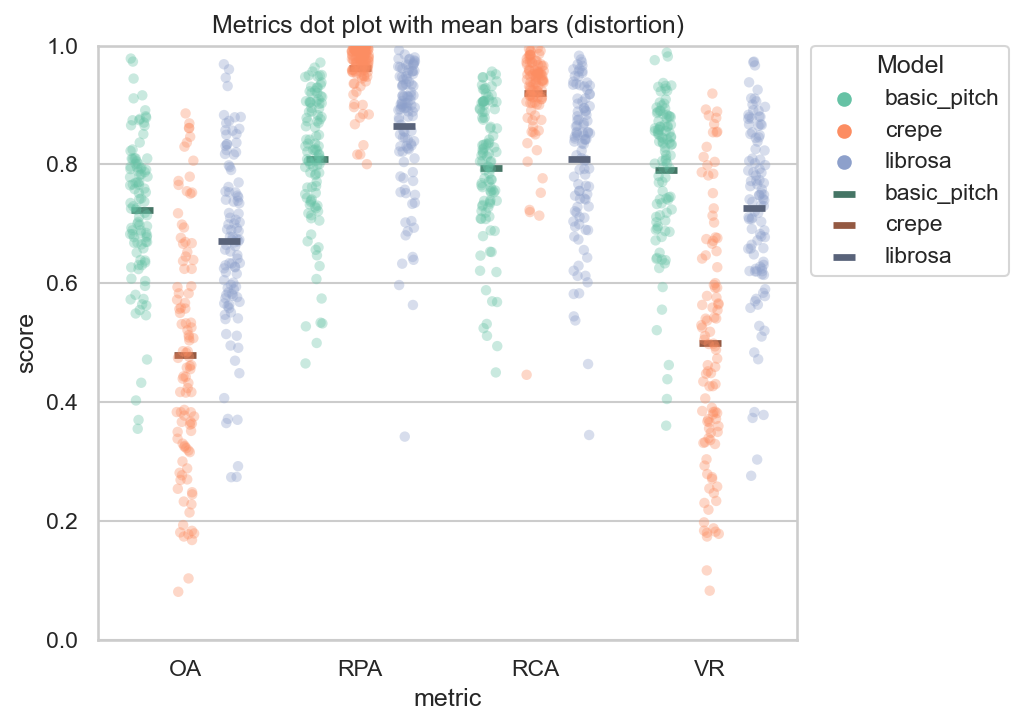

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.26966710777846514, 0.4568837962313781, 0.39739568702782224)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

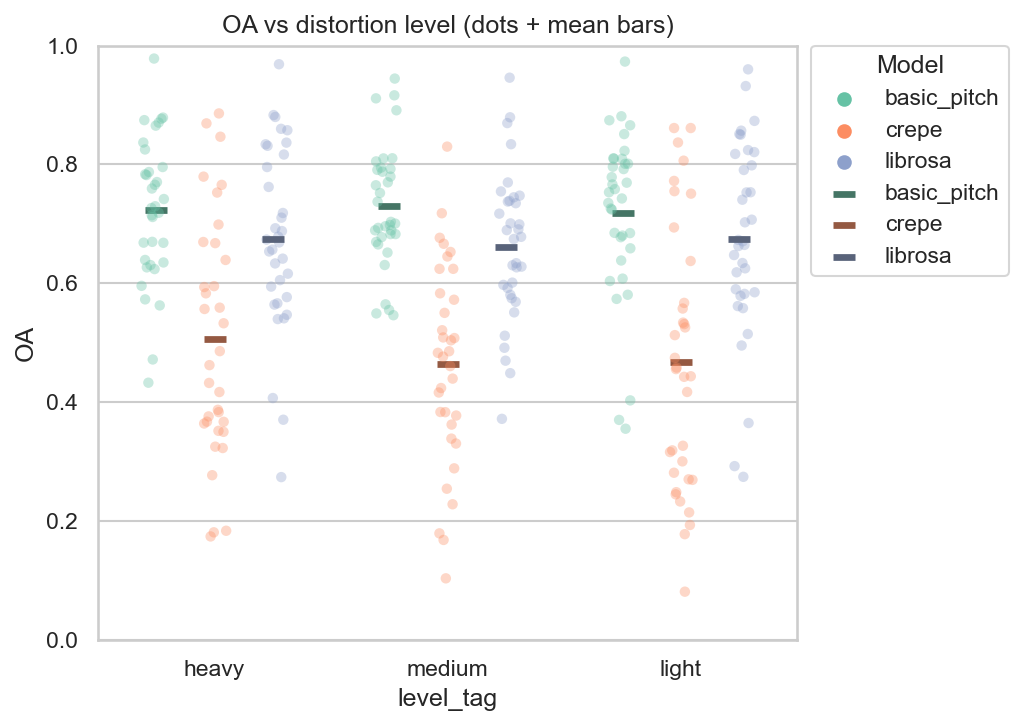

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.26966710777846514, 0.4568837962313781, 0.39739568702782224)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

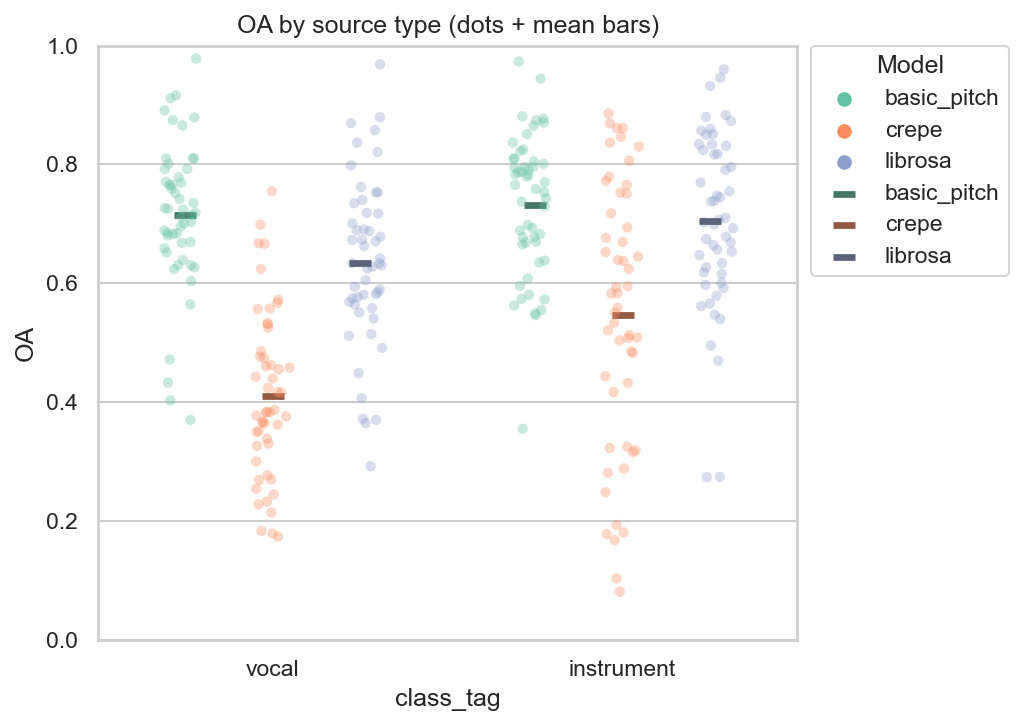

In [8]:
long_metrics = metrics.melt(
    id_vars=["filename", "model", "class_tag", "level_tag"],
    value_vars=["OA", "RPA", "RCA", "VR"],
    var_name="metric",
    value_name="score",
)

hue_order = sorted(metrics["model"].unique())
palette = sns.color_palette("Set2", n_colors=len(hue_order))
mean_palette = [sns.dark_palette(c, 3)[1] for c in palette]
color_map = dict(zip(hue_order, palette))
mean_map = dict(zip(hue_order, mean_palette))

# Plot 1: per-metric dots + mean bars (single figure)
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=long_metrics,
    x="metric",
    y="score",
    hue="model",
    hue_order=hue_order,
    palette=color_map,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=long_metrics,
    x="metric",
    y="score",
    hue="model",
    hue_order=hue_order,
    palette=[mean_map[h] for h in hue_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("Metrics dot plot with mean bars (distortion)")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "metrics_dot_mean.png", bbox_inches="tight")
plt.show()

# Plot 2: OA vs distortion level (single figure)
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=metrics,
    x="level_tag",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=color_map,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=metrics,
    x="level_tag",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=[mean_map[h] for h in hue_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("OA vs distortion level (dots + mean bars)")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "oa_level_dot_mean.png", bbox_inches="tight")
plt.show()

# Plot 3: OA by source type (single figure)
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=metrics,
    x="class_tag",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=color_map,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=metrics,
    x="class_tag",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=[mean_map[h] for h in hue_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("OA by source type (dots + mean bars)")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "oa_source_dot_mean.png", bbox_inches="tight")
plt.show()
